In [526]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

from playsound import playsound

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression

sys.path.append(os.path.abspath(".."))
from function import ART_bias
from function import ART_downscale as ART_down

import warnings
warnings.filterwarnings('ignore')

In [527]:
correction, nameout, label = 'Linear-Regression-origin', 'LTO', 'Linear Regression Origin'

In [528]:
product, time_reso = 'IMERG', '1dy'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

In [529]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')

dir_cal = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Calibration')
dir_val = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC','CAL_VAL', 'Validation')

## Load MEVd Data

In [530]:
# data_dir = os.path.join(dir_base, 'Satellite','5_DOWN', f'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
# data_dir = os.path.join(dir_base, 'Satellite','5_DOWN', f'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
data_dir = os.path.join(dir_base, 'Satellite','5_DOWN', f'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(data_dir)
lons_IM, lats_IM = DATA.lon.values, DATA.lat.values
lon2d_IM, lat2d_IM = np.meshgrid(lons_IM, lats_IM)

## Load METDATA

In [531]:
seeds_list = [7, 19, 31, 53, 89, 127, 211, 307, 401, 509, 613, 727, 839, 947, 1051]
seed = seeds_list[0]

METADATA_CAL = pd.read_csv(os.path.join(dir_cal, f'METADATA_CAL_seed{seed}.csv'))
METADATA_VAL = pd.read_csv(os.path.join(dir_val, f'METADATA_VAL_seed{seed}.csv'))

In [532]:
nn = 5

for iso in METADATA_CAL['ISO'].unique():
    name = METADATA_CAL[METADATA_CAL['ISO'] == iso]['File'].values[nn]
    ISO = METADATA_CAL[METADATA_CAL['ISO'] == iso]['ISO'].values[nn]
    lat_obs = METADATA_CAL[METADATA_CAL['ISO'] == iso]['Lat'].values[nn]
    lon_obs = METADATA_CAL[METADATA_CAL['ISO'] == iso]['Lon'].values[nn]

dir_station = os.path.join(dir_base,'Rain_Gauges_QC','Weibull','1dy',ISO,name)
DF_OBS = pd.read_csv(dir_station)
DF_OBS = DF_OBS.drop(columns='NaN')

print(f'Number of years: {len(DF_OBS)}')

Number of years: 16


In [533]:
PREC_DOWN = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

DF_SAT = pd.DataFrame({
                    'Year':PREC_DOWN.year.values, 
                    'Ns':PREC_DOWN.NYs.values, 'Cs':PREC_DOWN.CYs.values, 'Ws':PREC_DOWN.WYs.values,
                    'Nd':PREC_DOWN.NYd.values, 'Cd':PREC_DOWN.CYd.values, 'Wd':PREC_DOWN.WYd.values})

In [534]:
merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')

In [535]:
merged_df_clean = merged_df.dropna(subset=['N'])

In [536]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

In [541]:
x0 = 9.0*np.nanmean(merged_df_clean.C.values)
quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
QQ_OBS = np.where(flag, quant, np.nan)

x0 = 9.0*np.nanmean(merged_df_clean.Cs.values)
quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Ns.values, merged_df_clean.Cs.values, merged_df_clean.Ws.values, thresh=1)
QQ_SAT = np.where(flag, quant, np.nan)

x0 = 9.0*np.nanmean(merged_df_clean.Cd.values)
quant, flag = ART_down.mev_quant_update(Fi, x0, merged_df_clean.Nd.values, merged_df_clean.Cd.values, merged_df_clean.Wd.values, thresh=1)
QQ_DOWN = np.where(flag, quant, np.nan)

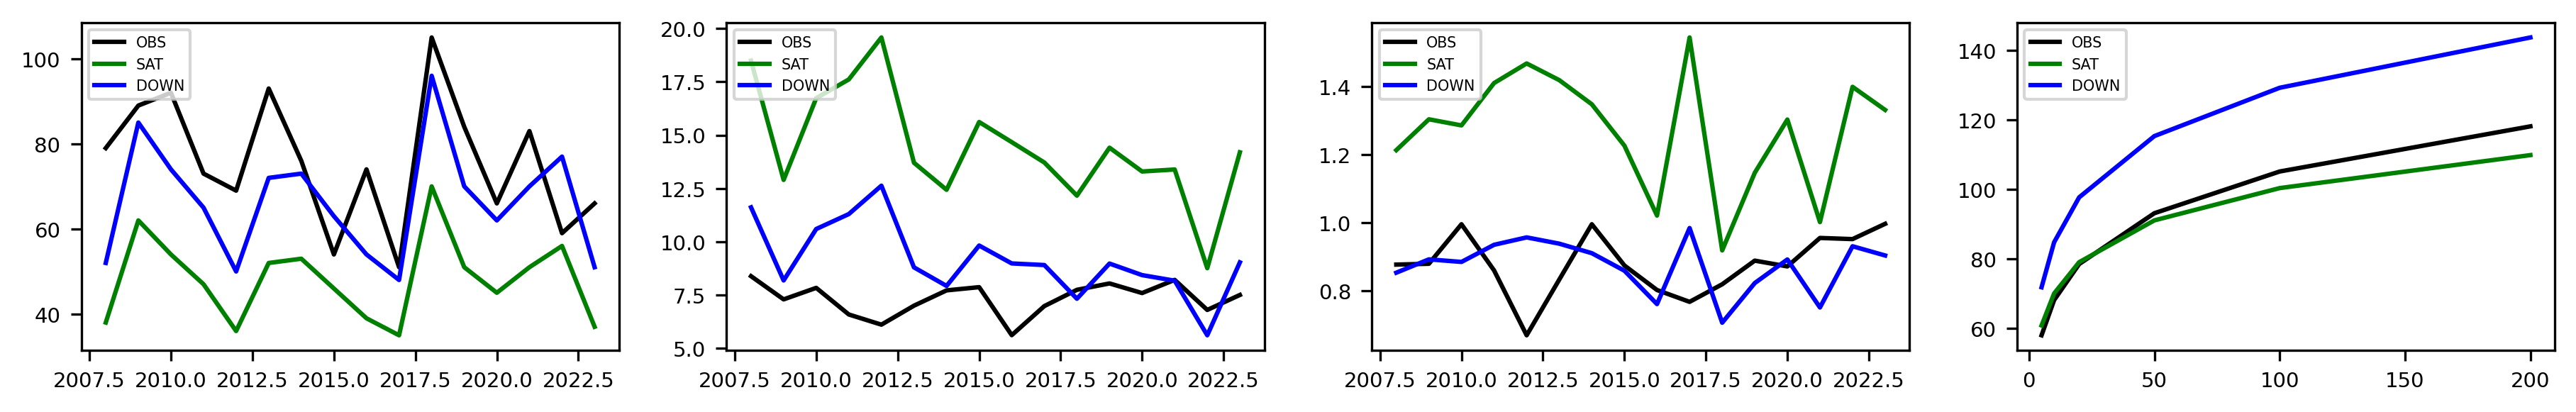

In [542]:
fig = plt.figure(figsize=(15,2),dpi=300)
gs = gridspec.GridSpec(1,4)

# =============================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot(merged_df_clean.Year, merged_df_clean.N, c='k', label='OBS')
ax1.plot(merged_df_clean.Year, merged_df_clean.Ns, c='g', label='SAT')
ax1.plot(merged_df_clean.Year, merged_df_clean.Nd, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2)
ax1.tick_params(axis='both', which='major', labelsize=7)

# =============================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.plot(merged_df_clean.Year, merged_df_clean.C, c='k', label='OBS')
ax1.plot(merged_df_clean.Year, merged_df_clean.Cs, c='g', label='SAT')
ax1.plot(merged_df_clean.Year, merged_df_clean.Cd, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2)
ax1.tick_params(axis='both', which='major', labelsize=7)

# =============================================================================
ax1 = plt.subplot(gs[0, 2])
ax1.plot(merged_df_clean.Year, merged_df_clean.W, c='k', label='OBS')
ax1.plot(merged_df_clean.Year, merged_df_clean.Ws, c='g', label='SAT')
ax1.plot(merged_df_clean.Year, merged_df_clean.Wd, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2)
ax1.tick_params(axis='both', which='major', labelsize=7)

# =============================================================================
ax1 = plt.subplot(gs[0, 3])
ax1.plot(Tr, QQ_OBS, c='k', label='OBS')
ax1.plot(Tr, QQ_SAT, c='g', label='SAT')
ax1.plot(Tr, QQ_DOWN, c='b', label='DOWN')
plt.legend(fontsize=5,loc=2)
ax1.tick_params(axis='both', which='major', labelsize=7)